# Comparisons of all-season ICESat-2 and CryoSat-2 sea ice thickness datasets with BGEP ULS sea ice draft estimates

**Summary:** In this notebook, we produce comparisons of all-season monthly gridded ICESat-2 and CryoSat-2 sea ice thickness data with draft measurements obtained from Upward Looking Sonar moorings deployed in the Beaufort Sea. 

**Author**: Alek Petty

**Version history**: 
 - Version 2 (09/25/2025): updated with new MERRA-2 and ERA5 snow loading and some other tweaks. 
 - Version 1 (05/01/2025)
 

# Import notebook dependencies

In [1]:
import xarray as xr 
import pandas as pd
import numpy as np
import itertools
import pyproj 
from netCDF4 import Dataset
import scipy.interpolate 
from utils.read_data_utils import read_book_data, read_IS2SITMOGR4 # Helper function for reading the data from the bucket
from utils.plotting_utils import compute_gridcell_winter_means, interactiveArcticMaps, interactive_winter_mean_maps, interactive_winter_comparison_lineplot # Plotting
from utils.extra_funcs import apply_interpolation_time
from scipy import stats
import datetime
# Plotting dependencies
import cartopy.crs as ccrs
from textwrap import wrap
import hvplot.pandas
import holoviews as hv
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from cartopy.mpl.geoaxes import GeoAxes
GeoAxes._pcolormesh_patched = Axes.pcolormesh # Helps avoid some weird issues with the polar projection 
%config InlineBackend.figure_format = 'retina'
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 00 # Sets figure size in the notebook

# Remove warnings to improve display
import warnings 
warnings.filterwarnings('ignore') 

ImportError: 

IMPORTANT: PLEASE READ THIS FOR ADVICE ON HOW TO SOLVE THIS ISSUE!

Importing the numpy C-extensions failed. This error can happen for
many reasons, often due to issues with your setup or how NumPy was
installed.

We have compiled some common reasons and troubleshooting tips at:

    https://numpy.org/devdocs/user/troubleshooting-importerror.html

Please note and check the following:

  * The Python version is: Python3.9 from "/Users/akpetty/miniconda3/envs/p39m/bin/python"
  * The NumPy version is: "1.24.4"

and make sure that they are the versions you expect.
Please carefully study the documentation linked above for further help.

Original error was: dlopen(/Users/akpetty/miniconda3/envs/p39m/lib/python3.9/site-packages/numpy/core/_multiarray_umath.cpython-39-darwin.so, 0x0002): Library not loaded: @rpath/libgfortran.5.dylib
  Referenced from: <342C6FCD-A261-33D7-B978-626161CFD49B> /Users/akpetty/miniconda3/envs/p39m/lib/libopenblas.0.dylib
  Reason: tried: '/Users/akp

In [ ]:
# Set some plotting parameters
mpl.rcParams.update({
    "text.usetex": False,  # Use LaTeX for rendering
    "font.family": "sans-serif",
    "lines.linewidth": 1.,
    "font.size": 8,
    #"lines.alpha": 0.8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
})
mpl.rcParams['font.sans-serif'] = ['Arial']
mpl.rcParams['figure.dpi'] = 300 

In [ ]:
reanalysis = 'e5'
reanalysis_two = 'm2'

start_date = "Nov 2018"
end_date = "July 2021"
options = {
    'IS2/SMLG-'+reanalysis.capitalize(): {'thickness': 'ice_thickness_sm_'+reanalysis+'_int', 'snow_depth': 'snow_depth_sm_'+reanalysis+'_int'},
    'IS2/SMLG-'+reanalysis_two.capitalize(): {'thickness': 'ice_thickness_sm_'+reanalysis_two+'_int', 'snow_depth': 'snow_depth_sm_'+reanalysis_two+'_int'},
    'CS2/SMLG-M2': {'thickness': 'ice_thickness_cs2_ubris', 'snow_depth': 'snow_depth_sm_m2_int'}
}


In [ ]:
# Load the all-season wrangled dataset
IS2_CS2_allseason = xr.open_dataset('./data/book_data_allseason_v2.nc')
print("Successfully loaded all-season wrangled dataset")

Successfully loaded all-season wrangled dataset


In [ ]:

# Get some map proj info needed for later functions
out_proj = 'EPSG:3411'
mapProj = pyproj.Proj("+init=" + out_proj)

xIS2 = IS2_CS2_allseason.x.values
yIS2 = IS2_CS2_allseason.y.values
xptsIS2, yptsIS2 = np.meshgrid(xIS2, yIS2)

out_lons = IS2_CS2_allseason.longitude.values
out_lats = IS2_CS2_allseason.latitude.values


In [ ]:
# List of (year, month) tuples where M2/SM is available
#summer_months = [
#    (2019, 5), (2019, 6), (2019, 8),  # 2019 May, June, August (not July)
#    (2020, 5), (2020, 6), (2020, 7), (2020, 8),  # 2020 May-Aug
#    (2021, 5), (2021, 6), (2021, 7)   # 2021 May-July
#]

# Create a boolean mask for these months
#def is_summer_month(time_index):
#    # time_index should be a pandas or numpy datetime64 array
#    return np.array([(d.year, d.month) in summer_months for d in pd.to_datetime(time_index)])

#summer_mask = is_summer_month(IS2_CS2_allseason['time'])

#reanalysis = 'm2'  # or however you want to set it

# Set your default variable names here:
#ice_thickness_default = 'ice_thickness_nesosim' + int_str  # example
#snow_depth_default = 'snow_depth_nesosim' + int_str        # example

#if reanalysis == 'm2':
#    IS2_CS2_allseason['ice_thickness_for_draft'] = (
#        IS2_CS2_allseason['ice_thickness_sm_m2'+int_str].where(m2_mask, IS2_CS2_allseason['ice_thickness_sm'+int_str])
#    )
#    IS2_CS2_allseason['snow_depth_for_draft'] = (
#        IS2_CS2_allseason['snow_depth_sm_m2'+int_str].where(m2_mask, IS2_CS2_allseason['snow_depth_sm'+int_str])
#    )
#    draft_label = 'IS-2/SM-LG-M2'
#else:
#    IS2_CS2_allseason['ice_thickness_for_draft'] = IS2_CS2_allseason['ice_thickness_sm_e5'+int_str]
#    IS2_CS2_allseason['snow_depth_for_draft'] = IS2_CS2_allseason['snow_depth_sm_e5'+int_str]
#    draft_label = 'IS-2/SM-LG-E5'

In [ ]:
# Estimate ice draft from the ICESat-2 data for more direct comparison with ULS draft measurements
# NB: Another option (not taken) is to simply multiply ULS drafts by 1.1 to convert to thickness (the AWI approach)
# Include int_str var = '_int' to use interpolated values.
int_str = '_int'
# Define the variables for each option

#IS-2
IS2_CS2_allseason[f'ice_draft_IS2/SMLG-'+reanalysis.capitalize()] = (IS2_CS2_allseason['ice_thickness_sm_'+reanalysis+int_str] - IS2_CS2_allseason['freeboard'+int_str] + IS2_CS2_allseason['snow_depth_sm_'+reanalysis+int_str])

IS2_CS2_allseason[f'ice_draft_IS2/SMLG-'+reanalysis_two.capitalize()] = (IS2_CS2_allseason['ice_thickness_sm_'+reanalysis_two+int_str] - IS2_CS2_allseason['freeboard'+int_str] + IS2_CS2_allseason['snow_depth_sm_'+reanalysis_two+int_str])

# CS-2
IS2_CS2_allseason[f'ice_draft_CS2/SMLG-M2'] = ((IS2_CS2_allseason['ice_thickness_cs2_ubris']*IS2_CS2_allseason['cs2_sea_ice_density_UBRIS']) + (IS2_CS2_allseason['snow_depth_sm_m2'+int_str] + IS2_CS2_allseason['snow_density_sm_m2'+int_str]))/1024.



In [ ]:
# Get date range

IS2_date_range = pd.date_range(start=start_date, end=end_date, freq='MS')+ pd.Timedelta(days=14)# MS indicates a time frequency of start of the month
#IS2_date_range = IS2_date_range[((IS2_date_range.month <5) | (IS2_date_range.month > 8))]
IS2_date_range_strs=[str(date.year)+'-%02d'%(date.month) for date in IS2_date_range]
#IS2_date_range_strs

In [ ]:
# This is the value in meters of the aggregation length-scale for the IS-2/CS-2 data. 
# A compromise between the 50km used in the original BGEP analysis and the 150km used in the Landy2022 analysis.
comp_res=100000

In [ ]:
# Wrangle the ULS data
# I use the raw data, bin it daily then monthly.

dataPathULS='./data/'

def get_ULS_dates(uls_mean_monthly_draft, uls_dates, date):
    #print(date)
    try:
        return uls_mean_monthly_draft[uls_dates==date].values[0]
    except:
        return np.nan

def get_uls_year(letter, year):
    if letter=='a':
        print('Mooring A (75.0 N, 150 W)')
        uls_x, uls_y = mapProj(-150., 75.)
    if letter=='b':
        print('Mooring B (78.4 N, 150.0 W)')
        uls_x, uls_y = mapProj(-150., 78.4)
    if letter=='d':
        print('Mooring D (74.0 N, 140.0 W)')
        uls_x, uls_y = mapProj(-140., 74.)
 
    uls = pd.read_csv(dataPathULS+'uls'+year+letter+'_draft.dat', sep='\s+',names = ['date', 'time', 'draft'], header=2)
    print(uls.head(10))
    utc_datetime_uls = pd.to_datetime(uls['date'], format='%Y%m%d')
    uls_mean_daily_draft = uls['draft'].groupby([utc_datetime_uls.dt.date]).mean() 

    uls_mean_monthly_draft = uls['draft'].groupby([utc_datetime_uls.dt.to_period('m')]).mean() 
    #print(uls_mean_monthly_draft)
    
    return uls_mean_daily_draft, uls_mean_monthly_draft, uls_x, uls_y


In [ ]:
uls_mean_daily_draft_a_18, uls_mean_monthly_draft_a_18, uls_x_a, uls_y_a = get_uls_year('a', '18')
uls_mean_daily_draft_b_18, uls_mean_monthly_draft_b_18, uls_x_b, uls_y_b = get_uls_year('b', '18')
uls_mean_daily_draft_d_18, uls_mean_monthly_draft_d_18, uls_x_d, uls_y_d = get_uls_year('d', '18')

Mooring A (75.0 N, 150 W)
       date    time  draft
0  20180925  234211    0.0
1  20180925  234212    0.0
2  20180925  234213    0.0
3  20180925  234214    0.0
4  20180925  234215    0.0
5  20180925  234216    0.0
6  20180925  234217    0.0
7  20180925  234218    0.0
8  20180925  234219    0.0
9  20180925  234220    0.0
Mooring B (78.4 N, 150.0 W)
       date   time  draft
0  20180923  20901    0.0
1  20180923  20902    0.0
2  20180923  20903    0.0
3  20180923  20904    0.0
4  20180923  20905    0.0
5  20180923  20906    0.0
6  20180923  20907    0.0
7  20180923  20908    0.0
8  20180923  20909    0.0
9  20180923  20910    0.0
Mooring D (74.0 N, 140.0 W)
       date   time  draft
0  20180915  10011    0.0
1  20180915  10012    0.0
2  20180915  10013    0.0
3  20180915  10014    0.0
4  20180915  10015    0.0
5  20180915  10016    0.0
6  20180915  10017    0.0
7  20180915  10018    0.0
8  20180915  10019    0.0
9  20180915  10020    0.0


In [ ]:
uls_mean_daily_draft_a_21, uls_mean_monthly_draft_a_21, _, _ = get_uls_year('a', '21')
uls_mean_daily_draft_b_21, uls_mean_monthly_draft_b_21, _, _ = get_uls_year('b', '21')
uls_mean_daily_draft_d_21, uls_mean_monthly_draft_d_21, _, _ = get_uls_year('d', '21')   

Mooring A (75.0 N, 150 W)
       date    time  draft
0  20210828  235411   2.11
1  20210828  235412   2.04
2  20210828  235413   1.96
3  20210828  235414   1.89
4  20210828  235415   1.82
5  20210828  235416   1.75
6  20210828  235417   1.68
7  20210828  235418   1.61
8  20210828  235419   1.54
9  20210828  235420   1.48
Mooring B (78.4 N, 150.0 W)
       date    time  draft
0  20210831  222825    0.0
1  20210831  222826    0.0
2  20210831  222827    0.0
3  20210831  222828    0.0
4  20210831  222829    0.0
5  20210831  222830    0.0
6  20210831  222831    0.0
7  20210831  222832    0.0
8  20210831  222833    0.0
9  20210831  222834    0.0
Mooring D (74.0 N, 140.0 W)
       date  time  draft
0  20210909  4745    0.0
1  20210909  4746    0.0
2  20210909  4747    0.0
3  20210909  4748    0.0
4  20210909  4749    0.0
5  20210909  4750    0.0
6  20210909  4751    0.0
7  20210909  4752    0.0
8  20210909  4753    0.0
9  20210909  4754    0.0


In [ ]:
# Combine data for all years
uls_mean_daily_draft_a = pd.concat([uls_mean_daily_draft_a_18, uls_mean_daily_draft_a_21])
uls_mean_daily_draft_b = pd.concat([uls_mean_daily_draft_b_18, uls_mean_daily_draft_b_21])
uls_mean_daily_draft_d = pd.concat([uls_mean_daily_draft_d_18, uls_mean_daily_draft_d_21])

# Combine data for all years
uls_mean_monthly_draft_a = pd.concat([uls_mean_monthly_draft_a_18, uls_mean_monthly_draft_a_21])
uls_mean_monthly_draft_b = pd.concat([uls_mean_monthly_draft_b_18, uls_mean_monthly_draft_b_21])
uls_mean_monthly_draft_d = pd.concat([uls_mean_monthly_draft_d_18, uls_mean_monthly_draft_d_21])

In [ ]:
end_date = "2021-08-01"
uls_mean_daily_draft_a = uls_mean_daily_draft_a[uls_mean_daily_draft_a.index < np.datetime64(end_date)].dropna()
uls_mean_daily_draft_b = uls_mean_daily_draft_b[uls_mean_daily_draft_b.index < np.datetime64(end_date)].dropna()
uls_mean_daily_draft_d = uls_mean_daily_draft_d[uls_mean_daily_draft_d.index < np.datetime64(end_date)].dropna()

uls_mean_monthly_draft_a = uls_mean_monthly_draft_a[uls_mean_monthly_draft_a.index < end_date].dropna()
uls_mean_monthly_draft_b = uls_mean_monthly_draft_b[uls_mean_monthly_draft_b.index < end_date].dropna()
uls_mean_monthly_draft_d = uls_mean_monthly_draft_d[uls_mean_monthly_draft_d.index < end_date].dropna()

start_date = "2018-11-01"
uls_mean_daily_draft_a = uls_mean_daily_draft_a[uls_mean_daily_draft_a.index >= np.datetime64(start_date)].dropna()
uls_mean_daily_draft_b = uls_mean_daily_draft_b[uls_mean_daily_draft_b.index >= np.datetime64(start_date)].dropna()
uls_mean_daily_draft_d = uls_mean_daily_draft_d[uls_mean_daily_draft_d.index >= np.datetime64(start_date)].dropna()

uls_mean_monthly_draft_a = uls_mean_monthly_draft_a[uls_mean_monthly_draft_a.index >= start_date].dropna()
uls_mean_monthly_draft_b = uls_mean_monthly_draft_b[uls_mean_monthly_draft_b.index >= start_date].dropna()
uls_mean_monthly_draft_d = uls_mean_monthly_draft_d[uls_mean_monthly_draft_d.index >= start_date].dropna()



In [ ]:
def grid_IS2_nearby(date, option, uls_x, uls_y, res=50000):
    #print(date)
    IS2 = IS2_CS2_allseason['ice_draft_'+option].sel(time=date)
    #xptsIS2g, yptsIS2g = mapProj(IS2.longitude.values, IS2.latitude.values)
    
    dist = np.sqrt((xptsIS2 - uls_x)**2 + (yptsIS2 - uls_y)**2)
    
    IS2_uls = IS2.where(dist<res).mean(skipna=True).values
    
    #print('Number of valid IS-2 grid cells in month '+str(date)[0:7]+':', np.count_nonzero(~np.isnan(IS2.where(dist<res))))
    
    #Another option I first explored, coarsen the data then do nearest neighbor...provided similar results but above is more flexible.
    #if coarse_res>1:
    #Coarsen array by coarse_res in x/y directions (note that each grid-cell represents 25 km so 4 = 100 km)
    #    IS2 = IS2.coarsen(x=res, y=res, boundary='pad').mean()
    #IS2_uls = scipy.interpolate.griddata((xptsIS2.flatten(), yptsIS2.flatten()), IS2.values.flatten(), (uls_x, uls_y), method = 'nearest')
    print(date, option, IS2_uls)
    return IS2_uls


# Compute monthly ULS values for each option
monthly_IS2_at_ULS_a_options = {}
monthly_IS2_at_ULS_b_options = {}
monthly_IS2_at_ULS_d_options = {}
monthly_IS2_at_ULS_all_options = {}

for option in options.keys():
    monthly_IS2_at_ULS_a_options[option] = [
        grid_IS2_nearby(date, option, uls_x_a, uls_y_a, res=comp_res) for date in IS2_date_range
    ]
    monthly_IS2_at_ULS_b_options[option] = [
        grid_IS2_nearby(date, option,uls_x_b, uls_y_b, res=comp_res) for date in IS2_date_range
    ]
    monthly_IS2_at_ULS_d_options[option] = [
        grid_IS2_nearby(date, option,uls_x_d, uls_y_d, res=comp_res) for date in IS2_date_range
    ]
    # Combine all ULS values for the current option
    monthly_IS2_at_ULS_all_options[option] = (
        monthly_IS2_at_ULS_a_options[option] +
        monthly_IS2_at_ULS_b_options[option] +
        monthly_IS2_at_ULS_d_options[option]
    )


2018-11-15 00:00:00 IS2/SMLG-E5 0.5941154
2018-12-15 00:00:00 IS2/SMLG-E5 0.94798076
2019-01-15 00:00:00 IS2/SMLG-E5 1.1232307
2019-02-15 00:00:00 IS2/SMLG-E5 1.3838845
2019-03-15 00:00:00 IS2/SMLG-E5 1.9214809
2019-04-15 00:00:00 IS2/SMLG-E5 2.057269
2019-05-15 00:00:00 IS2/SMLG-E5 2.1249423
2019-06-15 00:00:00 IS2/SMLG-E5 1.8776155
2019-07-15 00:00:00 IS2/SMLG-E5 nan
2019-08-15 00:00:00 IS2/SMLG-E5 nan
2019-09-15 00:00:00 IS2/SMLG-E5 nan
2019-10-15 00:00:00 IS2/SMLG-E5 nan
2019-11-15 00:00:00 IS2/SMLG-E5 0.60698074
2019-12-15 00:00:00 IS2/SMLG-E5 0.93857694
2020-01-15 00:00:00 IS2/SMLG-E5 1.1105962
2020-02-15 00:00:00 IS2/SMLG-E5 1.1857885
2020-03-15 00:00:00 IS2/SMLG-E5 1.4347501
2020-04-15 00:00:00 IS2/SMLG-E5 1.6431346
2020-05-15 00:00:00 IS2/SMLG-E5 1.8750578
2020-06-15 00:00:00 IS2/SMLG-E5 1.8289809
2020-07-15 00:00:00 IS2/SMLG-E5 0.70578855
2020-08-15 00:00:00 IS2/SMLG-E5 0.55099994
2020-09-15 00:00:00 IS2/SMLG-E5 0.639
2020-10-15 00:00:00 IS2/SMLG-E5 0.7787885
2020-11-15 00:00

In [ ]:
uls_dates=uls_mean_monthly_draft_a.index.astype(str)
uls_mean_monthly_draft_a_IS2_period  = [get_ULS_dates(uls_mean_monthly_draft_a, uls_dates, date) for date in IS2_date_range_strs]

uls_dates=uls_mean_monthly_draft_b.index.astype(str)
uls_mean_monthly_draft_b_IS2_period  = [get_ULS_dates(uls_mean_monthly_draft_b, uls_dates, date) for date in IS2_date_range_strs]

uls_dates=uls_mean_monthly_draft_d.index.astype(str)
uls_mean_monthly_draft_d_IS2_period  = [get_ULS_dates(uls_mean_monthly_draft_d, uls_dates, date) for date in IS2_date_range_strs]
                                        
uls_mean_monthly_draft_IS2_period = uls_mean_monthly_draft_a_IS2_period+uls_mean_monthly_draft_b_IS2_period+uls_mean_monthly_draft_d_IS2_period


In [ ]:
# Validation analysis for each option
validation_results = {}

for option in options.keys():
    print(option)
    # ULS A
    mask_a = ~np.isnan(monthly_IS2_at_ULS_a_options[option])& ~np.isnan(uls_mean_monthly_draft_a_IS2_period)
    res_a = stats.linregress(
        np.array(monthly_IS2_at_ULS_a_options[option])[mask_a],
        np.array(uls_mean_monthly_draft_a_IS2_period)[mask_a]
    )
    r_str_a = '%.02f' % (res_a[2]**2)
    mb_str_a = '%.02f' % (np.nanmean(np.array(monthly_IS2_at_ULS_a_options[option]) - np.array(uls_mean_monthly_draft_a_IS2_period)))
    sd_str_a = '%.02f' % (np.nanstd(np.array(monthly_IS2_at_ULS_a_options[option]) - np.array(uls_mean_monthly_draft_a_IS2_period)))

    # ULS B
    mask_b = ~np.isnan(monthly_IS2_at_ULS_b_options[option])& ~np.isnan(uls_mean_monthly_draft_b_IS2_period)
    res_b = stats.linregress(
        np.array(monthly_IS2_at_ULS_b_options[option])[mask_b],
        np.array(uls_mean_monthly_draft_b_IS2_period)[mask_b]
    )
    r_str_b = '%.02f' % (res_b[2]**2)
    mb_str_b = '%.02f' % (np.nanmean(np.array(monthly_IS2_at_ULS_b_options[option]) - np.array(uls_mean_monthly_draft_b_IS2_period)))
    sd_str_b = '%.02f' % (np.nanstd(np.array(monthly_IS2_at_ULS_b_options[option]) - np.array(uls_mean_monthly_draft_b_IS2_period)))

    # ULS D
    mask_d = ~np.isnan(monthly_IS2_at_ULS_d_options[option])& ~np.isnan(uls_mean_monthly_draft_b_IS2_period)
    res_d = stats.linregress(
        np.array(monthly_IS2_at_ULS_d_options[option])[mask_d],
        np.array(uls_mean_monthly_draft_d_IS2_period)[mask_d]
    )
    r_str_d = '%.02f' % (res_d[2]**2)
    mb_str_d = '%.02f' % (np.nanmean(np.array(monthly_IS2_at_ULS_d_options[option]) - np.array(uls_mean_monthly_draft_d_IS2_period)))
    sd_str_d = '%.02f' % (np.nanstd(np.array(monthly_IS2_at_ULS_d_options[option]) - np.array(uls_mean_monthly_draft_d_IS2_period)))

    # ULS ALL
    mask_all = ~np.isnan(monthly_IS2_at_ULS_all_options[option])& ~np.isnan(uls_mean_monthly_draft_IS2_period)
    res_all = stats.linregress(
        np.array(monthly_IS2_at_ULS_all_options[option])[mask_all],
        np.array(uls_mean_monthly_draft_IS2_period)[mask_all]
    )
    r_str_all = '%.02f' % (res_all[2]**2)
    mb_str_all = '%.02f' % (np.nanmean(np.array(monthly_IS2_at_ULS_all_options[option]) - np.array(uls_mean_monthly_draft_IS2_period)))
    sd_str_all = '%.02f' % (np.nanstd(np.array(monthly_IS2_at_ULS_all_options[option]) - np.array(uls_mean_monthly_draft_IS2_period)))

    # Store results
    validation_results[option] = {
        'r_str_a': r_str_a, 'mb_str_a': mb_str_a, 'sd_str_a': sd_str_a,
        'r_str_b': r_str_b, 'mb_str_b': mb_str_b, 'sd_str_b': sd_str_b,
        'r_str_d': r_str_d, 'mb_str_d': mb_str_d, 'sd_str_d': sd_str_d,
        'r_str_all': r_str_all, 'mb_str_all': mb_str_all, 'sd_str_all': sd_str_all
    }

validation_results

IS2/SMLG-E5
IS2/SMLG-M2
CS2/SMLG-M2


{'IS2/SMLG-E5': {'r_str_a': '0.79',
  'mb_str_a': '0.14',
  'sd_str_a': '0.24',
  'r_str_b': '0.72',
  'mb_str_b': '0.15',
  'sd_str_b': '0.31',
  'r_str_d': '0.85',
  'mb_str_d': '0.21',
  'sd_str_d': '0.26',
  'r_str_all': '0.76',
  'mb_str_all': '0.16',
  'sd_str_all': '0.27'},
 'IS2/SMLG-M2': {'r_str_a': '0.74',
  'mb_str_a': '0.01',
  'sd_str_a': '0.26',
  'r_str_b': '0.76',
  'mb_str_b': '0.07',
  'sd_str_b': '0.30',
  'r_str_d': '0.79',
  'mb_str_d': '0.16',
  'sd_str_d': '0.28',
  'r_str_all': '0.73',
  'mb_str_all': '0.08',
  'sd_str_all': '0.29'},
 'CS2/SMLG-M2': {'r_str_a': '0.74',
  'mb_str_a': '0.02',
  'sd_str_a': '0.26',
  'r_str_b': '0.82',
  'mb_str_b': '0.42',
  'sd_str_b': '0.28',
  'r_str_d': '0.77',
  'mb_str_d': '-0.10',
  'sd_str_d': '0.32',
  'r_str_all': '0.60',
  'mb_str_all': '0.11',
  'sd_str_all': '0.36'}}

In [ ]:
uls_mean_monthly_draft_a.index.to_timestamp()+ pd.Timedelta(days=14)

DatetimeIndex(['2018-11-15', '2018-12-15', '2019-01-15', '2019-02-15',
               '2019-03-15', '2019-04-15', '2019-05-15', '2019-06-15',
               '2019-07-15', '2019-08-15', '2019-09-15', '2019-10-15',
               '2019-11-15', '2019-12-15', '2020-01-15', '2020-02-15',
               '2020-03-15', '2020-04-15', '2020-05-15', '2020-06-15',
               '2020-07-15', '2020-08-15', '2020-09-15', '2020-10-15',
               '2020-11-15', '2020-12-15', '2021-01-15', '2021-02-15',
               '2021-03-15', '2021-04-15', '2021-05-15', '2021-06-15',
               '2021-07-15'],
              dtype='datetime64[ns]', name='date', freq=None)

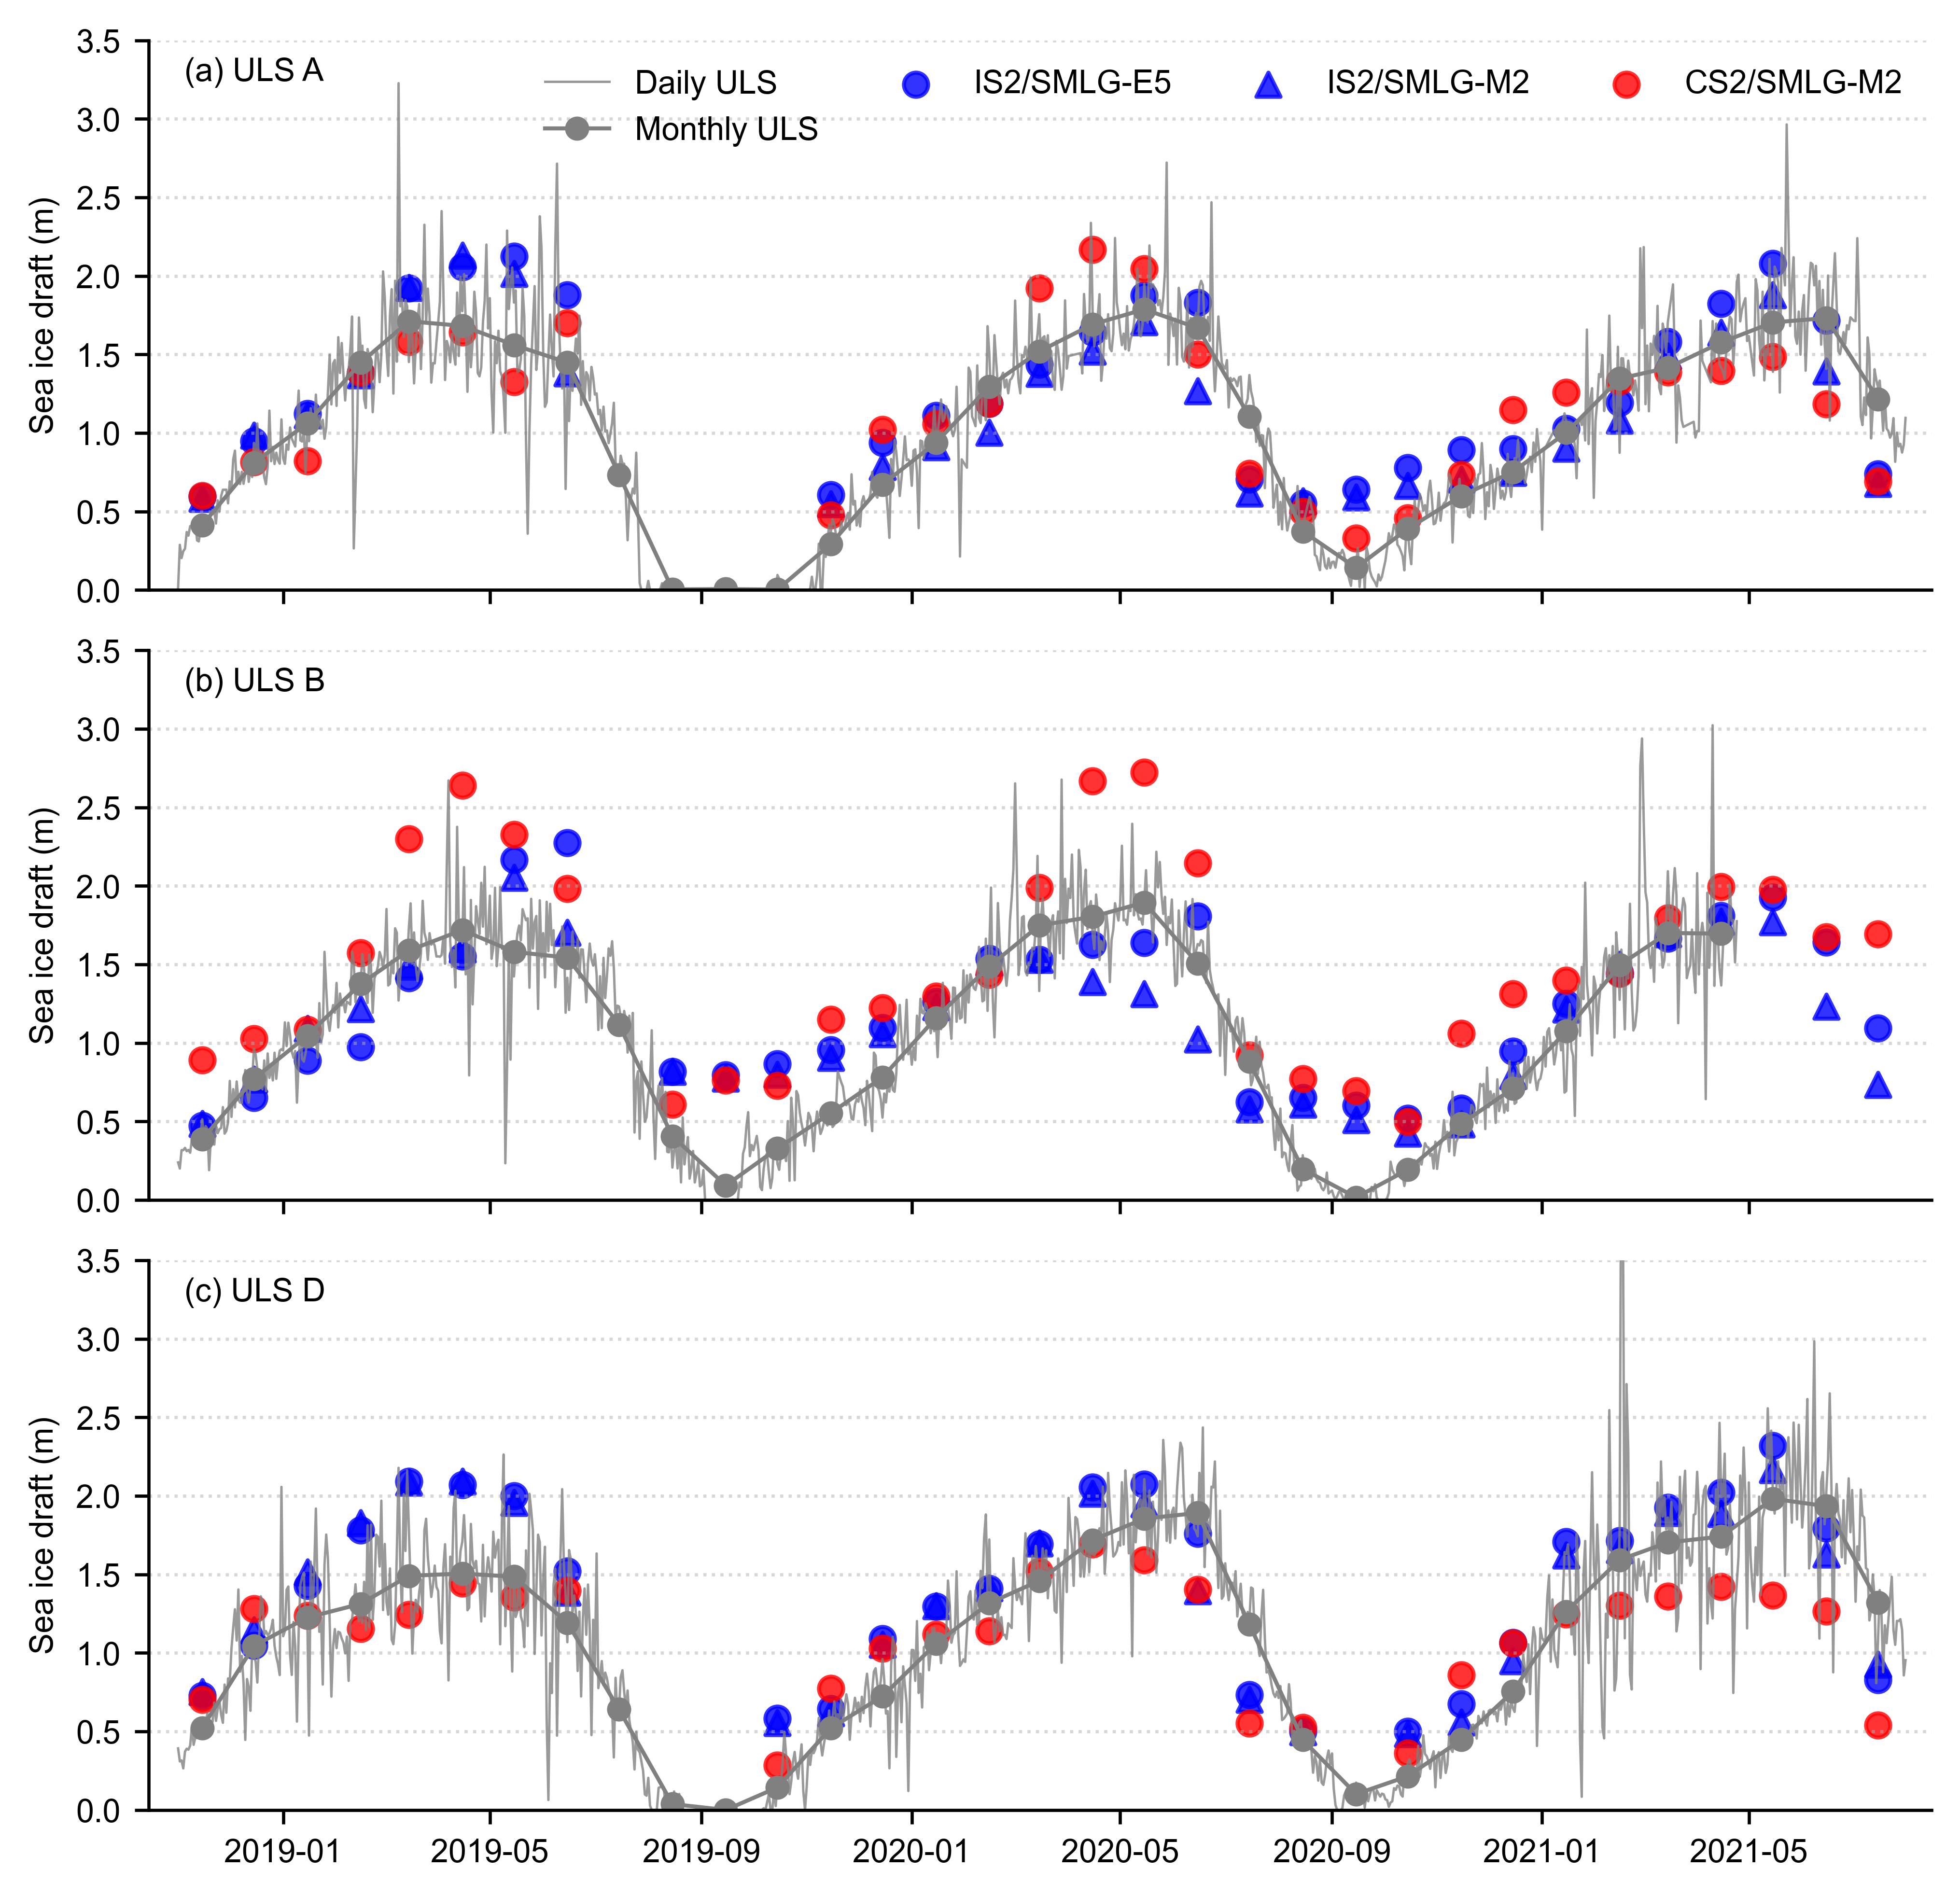

In [ ]:
# Define a function to create plots for a given option
option_labels = ['IS2/SMLG-'+reanalysis.capitalize(), 'IS2/SMLG-'+reanalysis_two.capitalize(), 'CS2/SMLG-M2']
fig, axes = plt.subplots(3, 1, figsize=(6.8, 6.5), sharex=True)

# Plot for ULS A
axes[0].plot(uls_mean_daily_draft_a.index, uls_mean_daily_draft_a, label="Daily ULS", color='gray', linewidth=0.6, alpha=0.8)
axes[0].plot(uls_mean_monthly_draft_a.index.to_timestamp() + pd.Timedelta(days=14), uls_mean_monthly_draft_a, label="Monthly ULS", marker='o', markersize=5, linewidth=1, alpha=1, color='gray')
axes[0].scatter(IS2_date_range, monthly_IS2_at_ULS_a_options[option_labels[0]], label=option_labels[0], color='b', marker='o', alpha=0.8)
axes[0].scatter(IS2_date_range, monthly_IS2_at_ULS_a_options[option_labels[1]], label=option_labels[1], color='b', marker='^', alpha=0.8)
axes[0].scatter(IS2_date_range, monthly_IS2_at_ULS_a_options[option_labels[2]], label=option_labels[2], color='r', marker='o', alpha=0.8)
#axes[0].scatter(IS2_date_range, uls_mean_monthly_draft_a_IS2_period, label=option, color='m', marker='x')

axes[0].annotate('(a) ULS A', xy=(0.02, 0.97), xycoords='axes fraction', verticalalignment='top')
axes[0].legend(loc='upper right', ncols=4, frameon=False)

# Plot for ULS B
axes[1].plot(uls_mean_daily_draft_b.index, uls_mean_daily_draft_b, label="Daily ULS", color='gray', linewidth=0.6, alpha=0.8)
axes[1].plot(uls_mean_monthly_draft_b.index.to_timestamp() + pd.Timedelta(days=14), uls_mean_monthly_draft_b, label="Monthly ULS", marker='o', markersize=5, linewidth=1, alpha=1, color='gray')
axes[1].scatter(IS2_date_range, monthly_IS2_at_ULS_b_options[option_labels[0]], label=option_labels[0], color='b', marker='o', alpha=0.8)
axes[1].scatter(IS2_date_range, monthly_IS2_at_ULS_b_options[option_labels[1]], label=option_labels[1], color='b', marker='^', alpha=0.8)
axes[1].scatter(IS2_date_range, monthly_IS2_at_ULS_b_options[option_labels[2]], label=option_labels[2], color='r', marker='o', alpha=0.8)

#axes[1].scatter(uls_mean_monthly_draft_b.index.to_timestamp() + pd.Timedelta(days=14), uls_mean_monthly_draft_b, label=option, color='b', marker='x')
axes[1].annotate('(b) ULS B', xy=(0.02, 0.97), xycoords='axes fraction', verticalalignment='top')


# Plot for ULS D
axes[2].plot(uls_mean_daily_draft_d.index, uls_mean_daily_draft_d, label="Daily ULS", color='gray', linewidth=0.6, alpha=0.8)
axes[2].plot(uls_mean_monthly_draft_d.index.to_timestamp() + pd.Timedelta(days=14), uls_mean_monthly_draft_d, label="Monthly ULS", marker='o', markersize=5, linewidth=1, alpha=1, color='gray')
#axes[2].scatter(IS2_date_range, uls_mean_monthly_draft_d_IS2_period , label=option, color='m', marker='x')
axes[2].scatter(IS2_date_range, monthly_IS2_at_ULS_d_options[option_labels[0]], label=option_labels[0], color='b', marker='o', alpha=0.8)
axes[2].scatter(IS2_date_range, monthly_IS2_at_ULS_d_options[option_labels[1]], label=option_labels[1], color='b', marker='^', alpha=0.8)
axes[2].scatter(IS2_date_range, monthly_IS2_at_ULS_d_options[option_labels[2]], label=option_labels[2], color='r', marker='o', alpha=0.8)

axes[2].annotate('(c) ULS D', xy=(0.02, 0.97), xycoords='axes fraction', verticalalignment='top')
axes[2].set_ylabel('Sea ice draft (m)')


for ax in axes:
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Add horizontal gridlines
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.set_ylim([0, 3.5])
    ax.set_ylabel('Sea ice draft (m)')
    ax.set_xlim([pd.Timestamp('2018-10-15'), pd.Timestamp('2021-08-15')])


plt.subplots_adjust(left=0.065, right=0.97, top=0.98, bottom=0.04, hspace=0.11)  # Adjust these values to reduce whitespace
plt.savefig('./figs/BGEP_allseason_res'+str(comp_res)+'_nn_'+start_date+end_date+int_str+'_inccs2_'+reanalysis+'-'+reanalysis_two+'_v2.pdf', dpi=300)
plt.show()


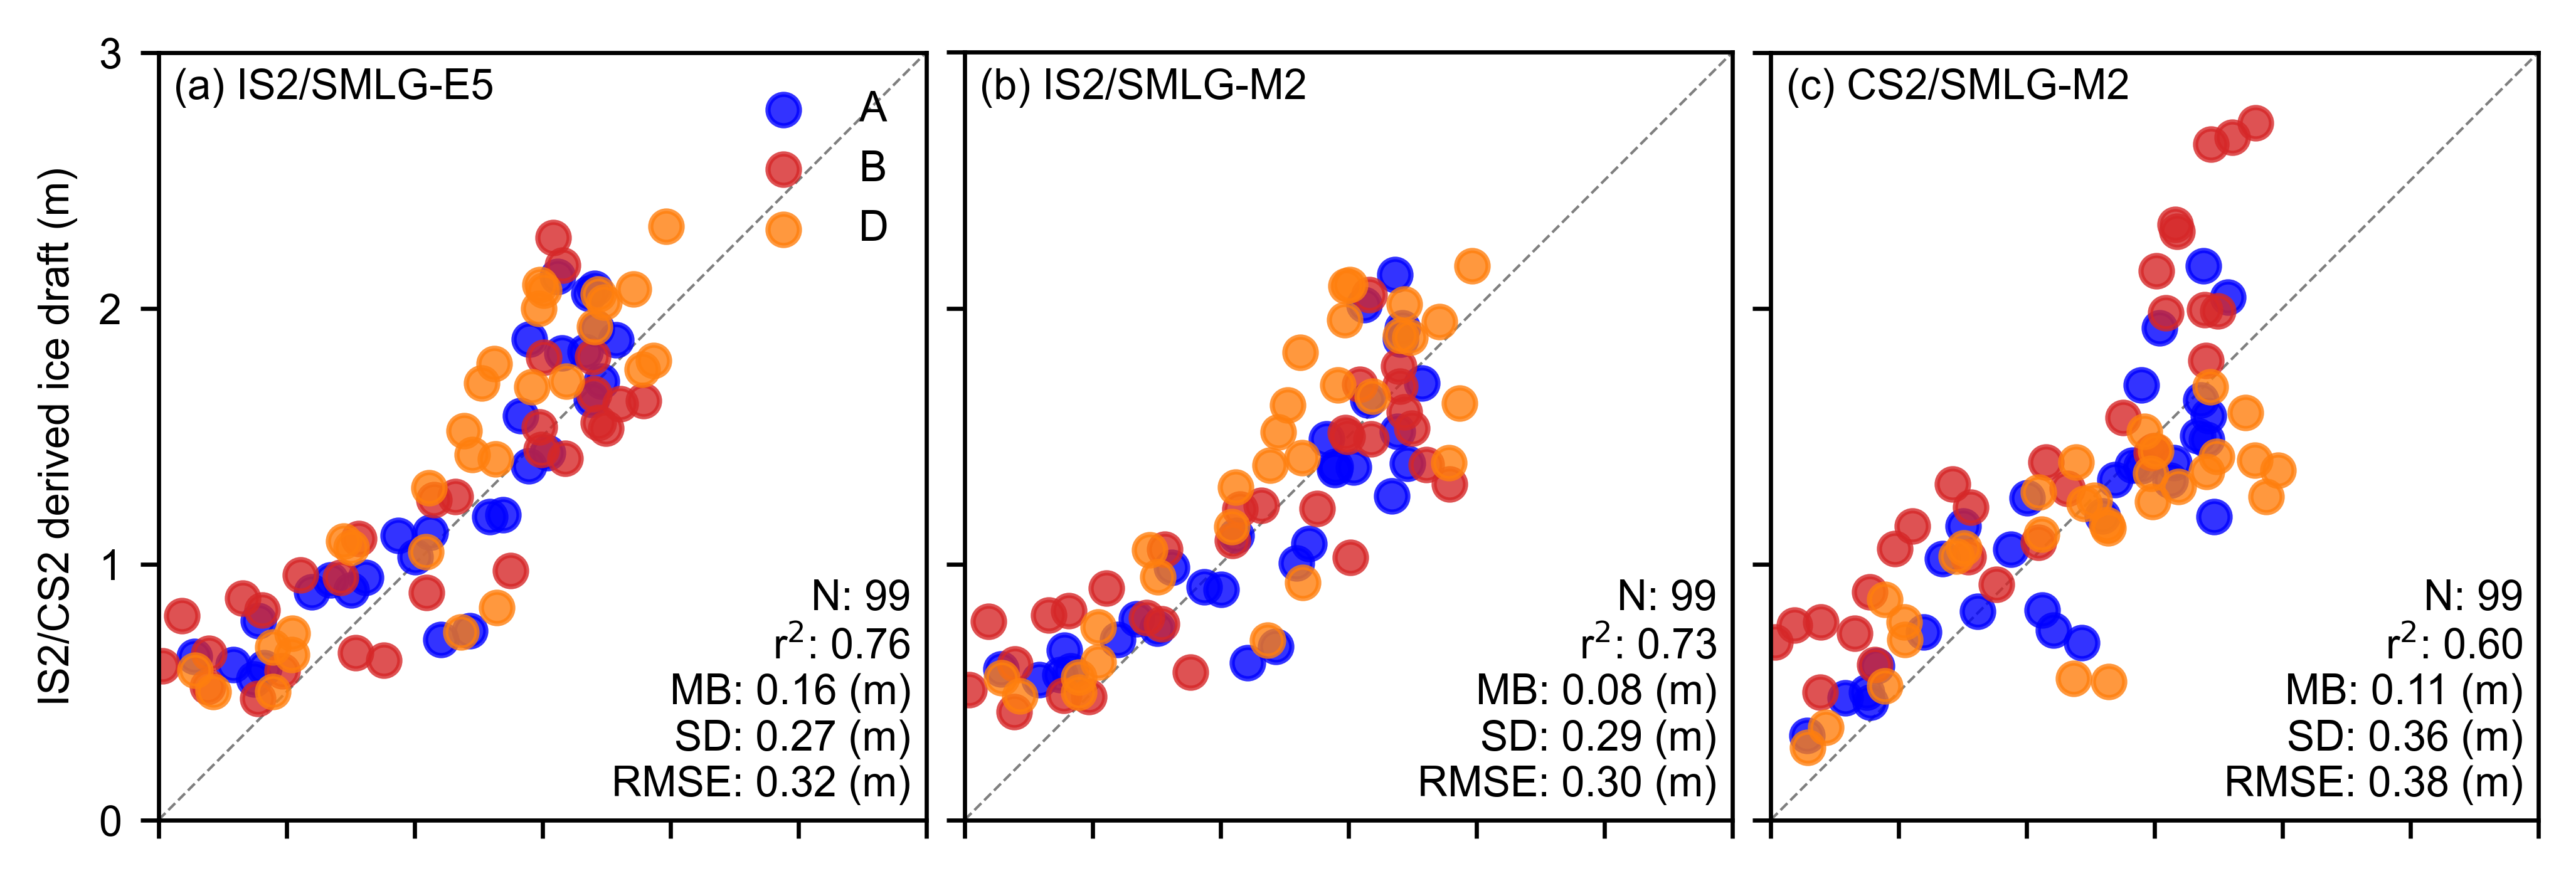

In [ ]:
# Create a single column with two rows for the two options
fig, axes = plt.subplots(1, 3, figsize=(6.8, 2.3), gridspec_kw={'wspace': 0.05})  # Adjust hspace for less whitespace
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
panel_labels = ['(a)', '(b)', '(c)']  # Panel labels

# Iterate over the first two options
for i, option in enumerate(list(options.keys())[:3]):
    ax = axes[i]
    ax.scatter(uls_mean_monthly_draft_a_IS2_period, monthly_IS2_at_ULS_a_options[option], color='b', alpha=0.8, label='A')
    ax.scatter(uls_mean_monthly_draft_b_IS2_period, monthly_IS2_at_ULS_b_options[option], color='tab:red', alpha=0.8, label='B')
    ax.scatter(uls_mean_monthly_draft_d_IS2_period, monthly_IS2_at_ULS_d_options[option], color='tab:orange', alpha=0.8, label='D')

    # Retrieve validation results for the current option
    r_str_all = validation_results[option]['r_str_all']
    mb_str_all = validation_results[option]['mb_str_all']
    sd_str_all = validation_results[option]['sd_str_all']
    rmse_all = np.sqrt(np.nanmean((np.array(monthly_IS2_at_ULS_all_options[option]) - np.array(uls_mean_monthly_draft_IS2_period))**2))
    n_str = str(len(monthly_IS2_at_ULS_all_options[option]))
    # Annotate the plot with RMSE, mean bias, and standard deviation
    ax.annotate(f"N: {n_str}\nr$^2$: {r_str_all}\nMB: {mb_str_all} (m)\nSD: {sd_str_all} (m)\nRMSE: {rmse_all:.02f} (m)", color='k', xy=(0.98, 0.02), xycoords='axes fraction', horizontalalignment='right', verticalalignment='bottom')

    # Combine panel label with option label
    ax.annotate(f"{panel_labels[i]} "+option, xy=(0.02, 0.98), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top')

    # Set x and y labels only for the leftmost and bottom plots
    if i == 0:
        ax.legend(frameon=False, loc="upper right")
        ax.set_ylabel('IS2/CS2 derived ice draft (m)')
    else:
        ax.set_yticklabels('')
    ax.set_xticklabels('')
    ax.set_xlabel('')
    
    

    ax.set_xlim([0, 3])
    ax.set_ylim([0, 3])
    ax.set_yticks([0, 1, 2, 3])
    
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    ax.plot(lims, lims, 'k--', linewidth=0.5, alpha=0.5, zorder=0)
    ax.set_aspect('equal')
    

plt.subplots_adjust(left=0.05, right=0.98, top=0.99, bottom=0.01)  # Adjust these values to reduce whitespace

plt.savefig('./figs/BGEP_allseason_scatter_res'+str(comp_res)+'_nn_'+start_date+end_date+int_str+'_inccs2_'+reanalysis+'v3.pdf', dpi=300)
plt.show()

# OK now just do summer month (May to August) comparisons!

In [ ]:
# Filter for summer months (May=5 through August=8)
IS2_date_range = IS2_date_range[IS2_date_range.month.isin([5, 6, 7, 8])]

# Create date strings for filtered range
IS2_date_range_strs = [str(date.year)+'-%02d'%(date.month) for date in IS2_date_range]

print("Summer dates:", IS2_date_range_strs)

Summer dates: ['2019-05', '2019-06', '2019-07', '2019-08', '2020-05', '2020-06', '2020-07', '2020-08', '2021-05', '2021-06', '2021-07']


In [ ]:
# Repeat functions from above (should really streamline this more)
# Compute monthly ULS values for each option
monthly_IS2_at_ULS_a_options = {}
monthly_IS2_at_ULS_b_options = {}
monthly_IS2_at_ULS_d_options = {}
monthly_IS2_at_ULS_all_options = {}

for option in options.keys():
    monthly_IS2_at_ULS_a_options[option] = [
        grid_IS2_nearby(date, option, uls_x_a, uls_y_a, res=comp_res) for date in IS2_date_range
    ]
    monthly_IS2_at_ULS_b_options[option] = [
        grid_IS2_nearby(date, option,uls_x_b, uls_y_b, res=comp_res) for date in IS2_date_range
    ]
    monthly_IS2_at_ULS_d_options[option] = [
        grid_IS2_nearby(date, option,uls_x_d, uls_y_d, res=comp_res) for date in IS2_date_range
    ]
    # Combine all ULS values for the current option
    monthly_IS2_at_ULS_all_options[option] = (
        monthly_IS2_at_ULS_a_options[option] +
        monthly_IS2_at_ULS_b_options[option] +
        monthly_IS2_at_ULS_d_options[option]
    )


2019-05-15 00:00:00 IS2/SMLG-E5 2.1249423
2019-06-15 00:00:00 IS2/SMLG-E5 1.8776155
2019-07-15 00:00:00 IS2/SMLG-E5 nan
2019-08-15 00:00:00 IS2/SMLG-E5 nan
2020-05-15 00:00:00 IS2/SMLG-E5 1.8750578
2020-06-15 00:00:00 IS2/SMLG-E5 1.8289809
2020-07-15 00:00:00 IS2/SMLG-E5 0.70578855
2020-08-15 00:00:00 IS2/SMLG-E5 0.55099994
2021-05-15 00:00:00 IS2/SMLG-E5 2.0777307
2021-06-15 00:00:00 IS2/SMLG-E5 1.71525
2021-07-15 00:00:00 IS2/SMLG-E5 0.7386345
2019-05-15 00:00:00 IS2/SMLG-E5 2.16676
2019-06-15 00:00:00 IS2/SMLG-E5 2.27472
2019-07-15 00:00:00 IS2/SMLG-E5 nan
2019-08-15 00:00:00 IS2/SMLG-E5 0.81884444
2020-05-15 00:00:00 IS2/SMLG-E5 1.6374398
2020-06-15 00:00:00 IS2/SMLG-E5 1.8070999
2020-07-15 00:00:00 IS2/SMLG-E5 0.62468004
2020-08-15 00:00:00 IS2/SMLG-E5 0.651
2021-05-15 00:00:00 IS2/SMLG-E5 1.9285
2021-06-15 00:00:00 IS2/SMLG-E5 1.64134
2021-07-15 00:00:00 IS2/SMLG-E5 1.0927
2019-05-15 00:00:00 IS2/SMLG-E5 1.99894
2019-06-15 00:00:00 IS2/SMLG-E5 1.5218371
2019-07-15 00:00:00 IS2/SM

In [ ]:
uls_dates=uls_mean_monthly_draft_a.index.astype(str)
uls_mean_monthly_draft_a_IS2_period  = [get_ULS_dates(uls_mean_monthly_draft_a, uls_dates, date) for date in IS2_date_range_strs]

uls_dates=uls_mean_monthly_draft_b.index.astype(str)
uls_mean_monthly_draft_b_IS2_period  = [get_ULS_dates(uls_mean_monthly_draft_b, uls_dates, date) for date in IS2_date_range_strs]

uls_dates=uls_mean_monthly_draft_d.index.astype(str)
uls_mean_monthly_draft_d_IS2_period  = [get_ULS_dates(uls_mean_monthly_draft_d, uls_dates, date) for date in IS2_date_range_strs]
                                        
uls_mean_monthly_draft_IS2_period = uls_mean_monthly_draft_a_IS2_period+uls_mean_monthly_draft_b_IS2_period+uls_mean_monthly_draft_d_IS2_period


In [ ]:
# Validation analysis for each option
validation_results = {}

for option in options.keys():
    print(option)
    # ULS A
    mask_a = ~np.isnan(monthly_IS2_at_ULS_a_options[option])& ~np.isnan(uls_mean_monthly_draft_a_IS2_period)
    res_a = stats.linregress(
        np.array(monthly_IS2_at_ULS_a_options[option])[mask_a],
        np.array(uls_mean_monthly_draft_a_IS2_period)[mask_a]
    )
    r_str_a = '%.02f' % (res_a[2]**2)
    mb_str_a = '%.02f' % (np.nanmean(np.array(monthly_IS2_at_ULS_a_options[option]) - np.array(uls_mean_monthly_draft_a_IS2_period)))
    sd_str_a = '%.02f' % (np.nanstd(np.array(monthly_IS2_at_ULS_a_options[option]) - np.array(uls_mean_monthly_draft_a_IS2_period)))

    # ULS B
    mask_b = ~np.isnan(monthly_IS2_at_ULS_b_options[option])& ~np.isnan(uls_mean_monthly_draft_b_IS2_period)
    res_b = stats.linregress(
        np.array(monthly_IS2_at_ULS_b_options[option])[mask_b],
        np.array(uls_mean_monthly_draft_b_IS2_period)[mask_b]
    )
    r_str_b = '%.02f' % (res_b[2]**2)
    mb_str_b = '%.02f' % (np.nanmean(np.array(monthly_IS2_at_ULS_b_options[option]) - np.array(uls_mean_monthly_draft_b_IS2_period)))
    sd_str_b = '%.02f' % (np.nanstd(np.array(monthly_IS2_at_ULS_b_options[option]) - np.array(uls_mean_monthly_draft_b_IS2_period)))

    # ULS D
    mask_d = ~np.isnan(monthly_IS2_at_ULS_d_options[option])& ~np.isnan(uls_mean_monthly_draft_b_IS2_period)
    res_d = stats.linregress(
        np.array(monthly_IS2_at_ULS_d_options[option])[mask_d],
        np.array(uls_mean_monthly_draft_d_IS2_period)[mask_d]
    )
    r_str_d = '%.02f' % (res_d[2]**2)
    mb_str_d = '%.02f' % (np.nanmean(np.array(monthly_IS2_at_ULS_d_options[option]) - np.array(uls_mean_monthly_draft_d_IS2_period)))
    sd_str_d = '%.02f' % (np.nanstd(np.array(monthly_IS2_at_ULS_d_options[option]) - np.array(uls_mean_monthly_draft_d_IS2_period)))

    # ULS ALL
    mask_all = ~np.isnan(monthly_IS2_at_ULS_all_options[option])& ~np.isnan(uls_mean_monthly_draft_IS2_period)
    res_all = stats.linregress(
        np.array(monthly_IS2_at_ULS_all_options[option])[mask_all],
        np.array(uls_mean_monthly_draft_IS2_period)[mask_all]
    )
    r_str_all = '%.02f' % (res_all[2]**2)
    mb_str_all = '%.02f' % (np.nanmean(np.array(monthly_IS2_at_ULS_all_options[option]) - np.array(uls_mean_monthly_draft_IS2_period)))
    sd_str_all = '%.02f' % (np.nanstd(np.array(monthly_IS2_at_ULS_all_options[option]) - np.array(uls_mean_monthly_draft_IS2_period)))

    # Store results
    validation_results[option] = {
        'r_str_a': r_str_a, 'mb_str_a': mb_str_a, 'sd_str_a': sd_str_a,
        'r_str_b': r_str_b, 'mb_str_b': mb_str_b, 'sd_str_b': sd_str_b,
        'r_str_d': r_str_d, 'mb_str_d': mb_str_d, 'sd_str_d': sd_str_d,
        'r_str_all': r_str_all, 'mb_str_all': mb_str_all, 'sd_str_all': sd_str_all
    }

validation_results

IS2/SMLG-E5
IS2/SMLG-M2
CS2/SMLG-M2


{'IS2/SMLG-E5': {'r_str_a': '0.71',
  'mb_str_a': '0.10',
  'sd_str_a': '0.33',
  'r_str_b': '0.70',
  'mb_str_b': '0.28',
  'sd_str_b': '0.36',
  'r_str_d': '0.73',
  'mb_str_d': '0.03',
  'sd_str_d': '0.33',
  'r_str_all': '0.67',
  'mb_str_all': '0.12',
  'sd_str_all': '0.36'},
 'IS2/SMLG-M2': {'r_str_a': '0.61',
  'mb_str_a': '-0.12',
  'sd_str_a': '0.33',
  'r_str_b': '0.53',
  'mb_str_b': '0.01',
  'sd_str_b': '0.42',
  'r_str_d': '0.61',
  'mb_str_d': '-0.08',
  'sd_str_d': '0.33',
  'r_str_all': '0.59',
  'mb_str_all': '-0.07',
  'sd_str_all': '0.36'},
 'CS2/SMLG-M2': {'r_str_a': '0.65',
  'mb_str_a': '-0.16',
  'sd_str_a': '0.29',
  'r_str_b': '0.92',
  'mb_str_b': '0.50',
  'sd_str_b': '0.27',
  'r_str_d': '0.65',
  'mb_str_d': '-0.37',
  'sd_str_d': '0.33',
  'r_str_all': '0.45',
  'mb_str_all': '-0.05',
  'sd_str_all': '0.46'}}

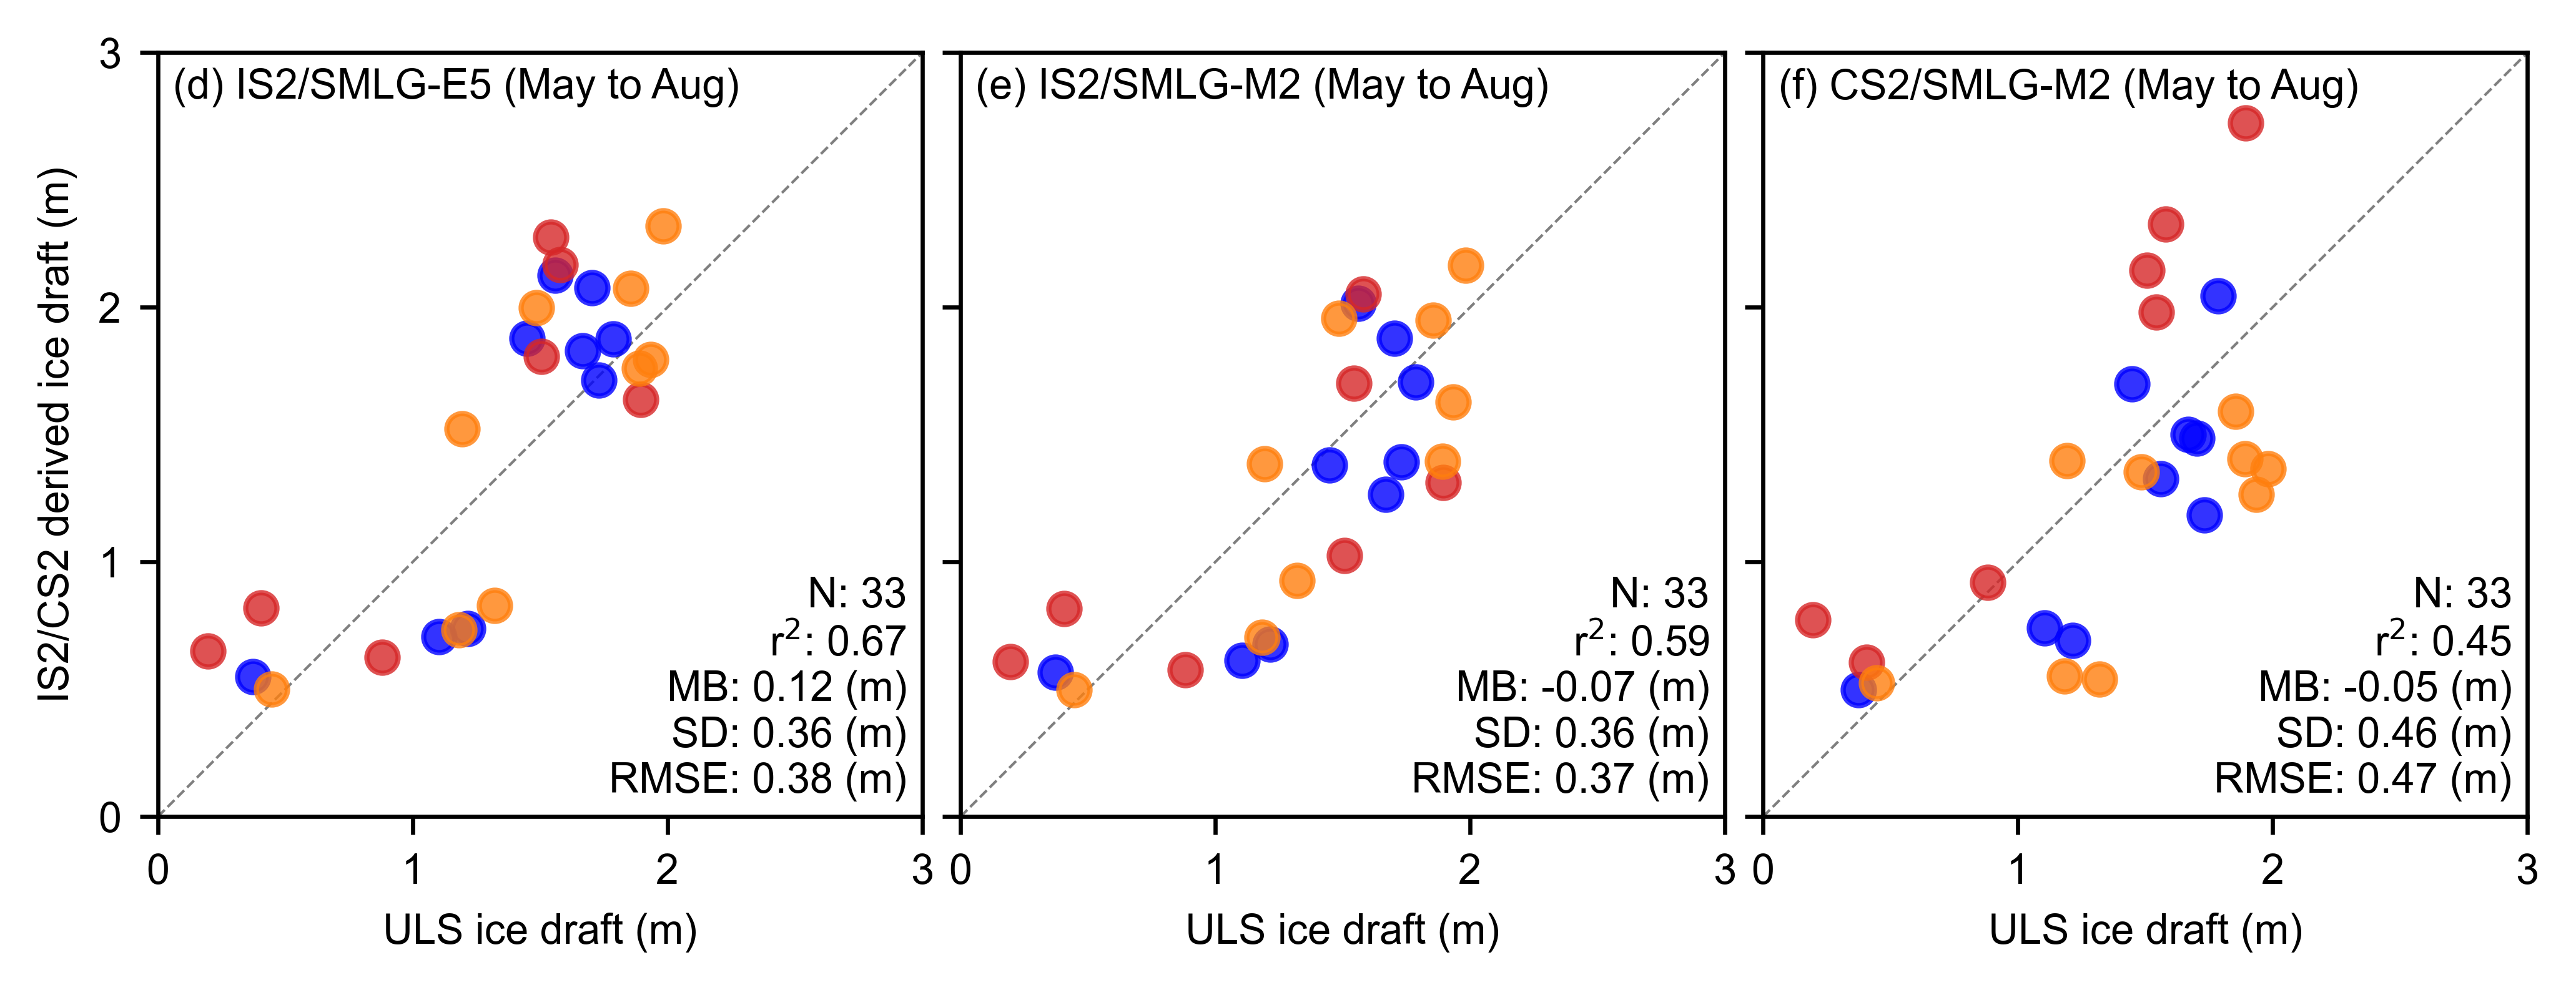

In [ ]:

# Create a single column with two rows for the two options
fig, axes = plt.subplots(1, 3, figsize=(6.8, 2.5), gridspec_kw={'wspace': 0.05})   # Adjust hspace for less whitespace
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
panel_labels = ['(d)', '(e)', '(f)']  # Panel labels

# Iterate over the first two options
for i, option in enumerate(list(options.keys())[:3]):
    ax = axes[i]
    ax.scatter(uls_mean_monthly_draft_a_IS2_period, monthly_IS2_at_ULS_a_options[option], color='b', alpha=0.8, label='A')
    ax.scatter(uls_mean_monthly_draft_b_IS2_period, monthly_IS2_at_ULS_b_options[option], color='tab:red', alpha=0.8, label='B')
    ax.scatter(uls_mean_monthly_draft_d_IS2_period, monthly_IS2_at_ULS_d_options[option], color='tab:orange', alpha=0.8, label='D')

    # Retrieve validation results for the current option
    r_str_all = validation_results[option]['r_str_all']
    mb_str_all = validation_results[option]['mb_str_all']
    sd_str_all = validation_results[option]['sd_str_all']
    rmse_all = np.sqrt(np.nanmean((np.array(monthly_IS2_at_ULS_all_options[option]) - np.array(uls_mean_monthly_draft_IS2_period))**2))
    n_str = str(len(monthly_IS2_at_ULS_all_options[option]))
    # Annotate the plot with RMSE, mean bias, and standard deviation
    ax.annotate(f"N: {n_str}\nr$^2$: {r_str_all}\nMB: {mb_str_all} (m)\nSD: {sd_str_all} (m)\nRMSE: {rmse_all:.02f} (m)", color='k', xy=(0.98, 0.02), xycoords='axes fraction', horizontalalignment='right', verticalalignment='bottom')

    # Combine panel label with option label
    ax.annotate(f"{panel_labels[i]} "+option+' (May to Aug)', xy=(0.02, 0.98), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top')

    # Set x and y labels only for the leftmost and bottom plots
    if i == 0:
        #ax.legend(frameon=False, loc="upper right")
        ax.set_ylabel('IS2/CS2 derived ice draft (m)')
    else:
        ax.set_yticklabels('')
    ax.set_xlabel('ULS ice draft (m)')

    #ax.set_ylabel('IS-2/CS-2 derived ice draft (m)')
    
    ax.set_ylim([0, 3])
    ax.set_yticks([0, 1, 2, 3])
    ax.set_xlim([0, 3])
    ax.set_xticks([0, 1, 2, 3])
    
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    ax.plot(lims, lims, 'k--', linewidth=0.5, alpha=0.5, zorder=0)
    ax.set_aspect('equal')
    

plt.subplots_adjust(left=0.05, right=0.98, top=0.99, bottom=0.11)  # Adjust these values to reduce whitespace
plt.savefig('./figs/BGEP_summer_scatter_res'+str(comp_res)+'_nn_'+start_date+end_date+int_str+'_inccs2_'+reanalysis+'v3.pdf', dpi=300)
plt.show()